### Now, after doing the statistical analysis. It's time for the ML Modeling

1. Train/Test Split
2. Handle Class Imbalance (SMOTE)
3. Feature Scaling
4. Train Multiple Models
5. Evaluate and Compare
6. Pick the Best Model

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df = pd.read_csv('diabetes_cleaned.csv')
print(df.shape)
print(df.columns.tolist())

(95103, 14)
['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'smoking_current', 'smoking_ever', 'smoking_former', 'smoking_never', 'smoking_not current', 'smoking_unknown']


Clean Data
    ↓
1. Split          → Train set (80%) + Test set (20%)
    ↓
2. Balance        → Fix 91/9 imbalance using SMOTE
    ↓
3. Scale          → Normalize feature ranges
    ↓
4. Train Models   → Logistic Regression, Random Forest, XGBoost
    ↓
5. Evaluate       → Accuracy, Precision, Recall, F1, ROC-AUC
    ↓
6. Compare        → Pick the best model
    ↓
7. Save           → Export model for web app

In [4]:
#Separate the features and target variable
X = df.drop('diabetes', axis=1)
y = df['diabetes']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution before split:")
print(y.value_counts(normalize=True).round(3) * 100)

Features shape: (95103, 13)
Target shape: (95103,)

Class distribution before split:
diabetes
0    91.1
1     8.9
Name: proportion, dtype: float64


In [5]:
# now, we've to split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% for testing
    random_state=42,      # reproducibility
    stratify=y            # maintain class ratio in both splits
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining class balance:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print("\nTesting class balance:")
print(y_test.value_counts(normalize=True).round(3) * 100)

Training set size: (76082, 13)
Testing set size: (19021, 13)

Training class balance:
diabetes
0    91.1
1     8.9
Name: proportion, dtype: float64

Testing class balance:
diabetes
0    91.1
1     8.9
Name: proportion, dtype: float64


* The random state is set to 42 as a reference to The Hitchhiker's Guide to the Galaxy by Douglas Adams. In the book, a supercomputer named Deep Thought    
  calculates the answer to the ultimate question of life, the universe, and everything — and after 7.5 million years, the answer is simply 42.
  And it can be any integer, not just 42

In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())
print("\nNew training set size:", X_train_balanced.shape)

Before SMOTE:
diabetes
0    69313
1     6769
Name: count, dtype: int64

After SMOTE:
diabetes
0    69313
1    69313
Name: count, dtype: int64

New training set size: (138626, 13)


In [7]:
print("Class balance after SMOTE:")
print(y_train_balanced.value_counts(normalize=True).round(3) * 100)


Class balance after SMOTE:
diabetes
0    50.0
1    50.0
Name: proportion, dtype: float64


In [8]:
# now, we've to scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)
print("Scaling done ")
print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Scaling done 
Training set shape: (138626, 13)
Testing set shape: (19021, 13)


In [9]:
# now, we've to verify whether the scaling worked or not
# Convert scaled arrays back to DataFrames for easier visualization
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns) 
print("\nMean of each feature (should be ~0):")
print(X_train_scaled_df.mean().round(3))
print("\nStd of each feature (should be ~1):")
print(X_train_scaled_df.std().round(3))


Mean of each feature (should be ~0):
gender                -0.0
age                   -0.0
hypertension          -0.0
heart_disease          0.0
bmi                    0.0
HbA1c_level           -0.0
blood_glucose_level    0.0
smoking_current        0.0
smoking_ever           0.0
smoking_former         0.0
smoking_never          0.0
smoking_not current    0.0
smoking_unknown       -0.0
dtype: float64

Std of each feature (should be ~1):
gender                 1.0
age                    1.0
hypertension           1.0
heart_disease          1.0
bmi                    1.0
HbA1c_level            1.0
blood_glucose_level    1.0
smoking_current        1.0
smoking_ever           1.0
smoking_former         1.0
smoking_never          1.0
smoking_not current    1.0
smoking_unknown        1.0
dtype: float64


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score)

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train and evaluate each
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train_balanced)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4)
    }
    print(f"  Done ")

print("\nAll models trained.")

Training Logistic Regression...
  Done 
Training Random Forest...
  Done 
Training XGBoost...
  Done 

All models trained.


In [12]:
results_df = pd.DataFrame(results).T
print("===== MODEL COMPARISON =====")
print(results_df)

===== MODEL COMPARISON =====
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.9266     0.5644  0.7636    0.6491   0.9542
Random Forest          0.9628     0.8471  0.7104    0.7727   0.9631
XGBoost                0.9678     0.9245  0.6950    0.7935   0.9754


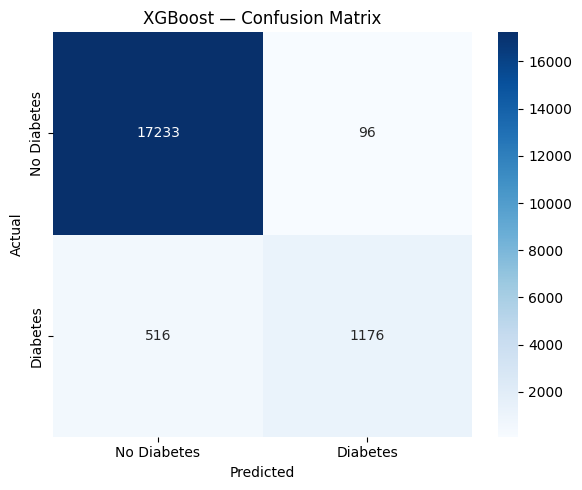

In [13]:
#confusion matrix
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay

best_model = models['XGBoost']
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [14]:
print("===== CLASSIFICATION REPORT — XGBoost =====")
print(classification_report(y_test, y_pred, 
      target_names=['No Diabetes', 'Diabetes']))

===== CLASSIFICATION REPORT — XGBoost =====
              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     17329
    Diabetes       0.92      0.70      0.79      1692

    accuracy                           0.97     19021
   macro avg       0.95      0.84      0.89     19021
weighted avg       0.97      0.97      0.97     19021



c:\Projects\Prob_Project\venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


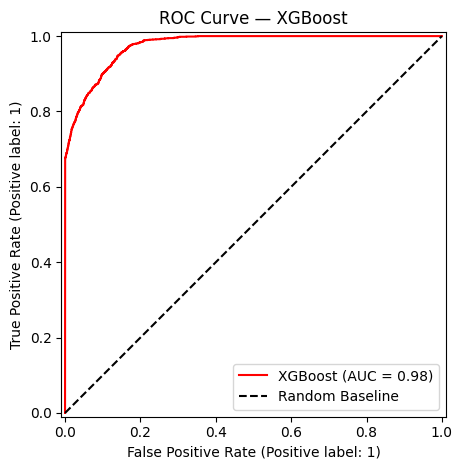

In [15]:
RocCurveDisplay.from_predictions(y_test, y_prob, 
                                  name='XGBoost',
                                  color='red')
plt.title('ROC Curve — XGBoost')
plt.plot([0,1],[0,1],'k--', label='Random Baseline')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
import joblib

# Save the model, scaler, and feature names
joblib.dump(best_model, 'xgboost_diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print("Model saved ")
print("Scaler saved ")
print("Feature names saved ")

Model saved 
Scaler saved 
Feature names saved 
